# GPT from scratch

Build each piece, smoke-test it with tiny tensors, then assemble and train on *The Verdict*.

*Flow:* tokenizer → dataset → embeddings → attention → block → GPT → generate → train

Site companion: `/build-from-scratch/gpt`.


## 0. Setup


In [1]:
import os
import importlib
from pathlib import Path

import requests
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("tiktoken:", importlib.metadata.version("tiktoken"))
print("torch:", torch.__version__)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    device = torch.device("mps") if (major, minor) >= (2, 9) else torch.device("cpu")
else:
    device = torch.device("cpu")

print("device:", device)
torch.manual_seed(123)


tiktoken: 0.14.0
torch: 2.14.0+cpu
device: cpu


In [4]:
# Shared config used by every module below (short context for fast training)
GPT_CONFIG = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}
GPT_CONFIG

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

## 1. Tokenizer

GPT-2 BPE via `tiktoken`. Encode text → integer IDs → decode back.


In [5]:
tokenizer = tiktoken.get_encoding("gpt2")

text = "Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace."
ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print("ids:", ids[:20], "...")
print("n_tokens:", len(ids))
print("decode:", tokenizer.decode(ids))

ids: [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 617, 34680, 27271, 13] ...
n_tokens: 20
decode: Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace.


## 2. Dataset and DataLoader

Sliding window over token IDs. Input is tokens `[t0..tN-1]`, target is the next-token shift `[t1..tN]`.


In [6]:
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, (
            "Need more than max_length tokens so targets can shift by 1"
        )

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk, dtype=torch.long))
            self.target_ids.append(torch.tensor(target_chunk, dtype=torch.long))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )


In [7]:
# Smoke test with a tiny string
tiny = "Hello, do you like tea? I like tea a lot. Tea is great when it rains."
loader = create_dataloader_v1(
    tiny, batch_size=2, max_length=4, stride=1, shuffle=False, drop_last=False
)
inputs, targets = next(iter(loader))
print("inputs:\n", inputs)
print("targets:\n", targets)
assert inputs.shape == targets.shape
assert torch.equal(inputs[:, 1:], targets[:, :-1])
print("shift check OK")


inputs:
 tensor([[15496,    11,   466,   345],
        [   11,   466,   345,   588]])
targets:
 tensor([[  11,  466,  345,  588],
        [ 466,  345,  588, 8887]])
shift check OK


## 3. Token and position embeddings

Each token ID → vector. Each position → vector. Sum them → model input.


In [8]:
vocab_size = GPT_CONFIG["vocab_size"]
emb_dim = 256  # small for the demo
max_length = inputs.shape[1]

token_embedding_layer = nn.Embedding(vocab_size, emb_dim)
pos_embedding_layer = nn.Embedding(max_length, emb_dim)

token_embeddings = token_embedding_layer(inputs)
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
input_embeddings = token_embeddings + pos_embeddings

print("token_embeddings:", token_embeddings.shape)
print("pos_embeddings:", pos_embeddings.shape)
print("input_embeddings:", input_embeddings.shape)


token_embeddings: torch.Size([2, 4, 256])
pos_embeddings: torch.Size([4, 256])
input_embeddings: torch.Size([2, 4, 256])


## 4. Self-attention

Single-head attention over a sequence (no batch, no causal mask yet).


In [9]:
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        # x: (seq, d_in)
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)
        scores = q @ k.T
        weights = torch.softmax(scores / k.shape[-1] ** 0.5, dim=-1)
        return weights @ v


In [10]:
x = torch.rand(3, 512)
sa = SelfAttention(512, 512)
out = sa(x)
print(out.shape)
assert out.shape == (3, 512)


torch.Size([3, 512])


## 5. Causal attention

Same idea, batched, with an upper-triangular mask so token *i* cannot attend to future tokens.


In [11]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        # x: (batch, seq, d_in)
        b, num_tokens, _ = x.shape
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        scores = q @ k.transpose(1, 2)
        scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        weights = torch.softmax(scores / k.shape[-1] ** 0.5, dim=-1)
        weights = self.dropout(weights)
        return weights @ v


In [12]:
batch = torch.rand(2, 3, 512)
ca = CausalAttention(512, 512, context_length=3, dropout=0.0)
out = ca(batch)
print(out.shape)
assert out.shape == (2, 3, 512)


torch.Size([2, 3, 512])


## 6. Multi-head attention

Split the embedding into *h* heads, run attention per head, merge, project out.

```
(B, S, d) → Q,K,V → (B, h, S, d/h) → scores → weights @ V → (B, S, d) → W_o
```


In [13]:
# Shape walkthrough (no class yet)
B, S, d_model, n_heads = 2, 8, 512, 8
d_head = d_model // n_heads
x = torch.rand(B, S, d_model)

wq = nn.Linear(d_model, d_model, bias=False)
wk = nn.Linear(d_model, d_model, bias=False)
wv = nn.Linear(d_model, d_model, bias=False)
wo = nn.Linear(d_model, d_model, bias=False)

q = wq(x).view(B, S, n_heads, d_head).transpose(1, 2)
k = wk(x).view(B, S, n_heads, d_head).transpose(1, 2)
v = wv(x).view(B, S, n_heads, d_head).transpose(1, 2)
print("heads:", q.shape)  # (B, h, S, d_head)

scores = (q @ k.transpose(-2, -1)) / (d_head ** 0.5)
mask = torch.triu(torch.ones(S, S, dtype=torch.bool), diagonal=1)
scores = scores.masked_fill(mask, -torch.inf)
weights = torch.softmax(scores, dim=-1)

context = (weights @ v).transpose(1, 2).contiguous().view(B, S, d_model)
out = wo(context)
print("out:", out.shape)
assert out.shape == (B, S, d_model)


heads: torch.Size([2, 8, 8, 64])
out: torch.Size([2, 8, 512])


In [14]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_emb, n_heads, context_length, dropout, qkv_bias=False):
        super().__init__()
        assert d_emb % n_heads == 0
        self.d_emb = d_emb
        self.n_heads = n_heads
        self.head_dim = d_emb // n_heads

        self.W_query = nn.Linear(d_emb, d_emb, bias=qkv_bias)
        self.W_key = nn.Linear(d_emb, d_emb, bias=qkv_bias)
        self.W_value = nn.Linear(d_emb, d_emb, bias=qkv_bias)
        self.W_output = nn.Linear(d_emb, d_emb, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1),
        )

    def forward(self, x):
        b, seq_len, _ = x.shape
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        q = q.view(b, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        scores = q @ k.transpose(2, 3)
        mask = self.mask.bool()[:seq_len, :seq_len]
        scores = scores.masked_fill(mask, -torch.inf)

        weights = torch.softmax(scores / self.head_dim ** 0.5, dim=-1)
        weights = self.dropout(weights)

        context = (weights @ v).transpose(1, 2).contiguous()
        context = context.view(b, seq_len, self.d_emb)
        return self.W_output(context)


In [15]:
cfg = GPT_CONFIG
x = torch.rand(2, 16, cfg["emb_dim"])
mha = MultiHeadAttention(
    d_emb=cfg["emb_dim"],
    n_heads=cfg["n_heads"],
    context_length=cfg["context_length"],
    dropout=0.0,
)
out = mha(x)
print(out.shape)
assert out.shape == x.shape


torch.Size([2, 16, 768])


## 7. LayerNorm, GELU, FeedForward

These wrap attention into a full transformer block.


In [16]:
class LayerNorm(nn.Module):
    def __init__(self, d_emb):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(d_emb))
        self.shift = nn.Parameter(torch.zeros(d_emb))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * x_norm + self.shift


In [17]:
x = torch.rand(2, 8, 512)
ln = LayerNorm(512)
x_norm = ln(x)
print("mean ~0:", x_norm.mean(dim=-1)[0, 0].item())
print("var  ~1:", x_norm.var(dim=-1, unbiased=False)[0, 0].item())


mean ~0: 5.4016709327697754e-08
var  ~1: 0.9998840689659119


In [18]:
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (
            1
            + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


In [19]:
x = torch.rand(2, 8, GPT_CONFIG["emb_dim"])
ffn = FeedForward(GPT_CONFIG)
out = ffn(x)
print(out.shape)
assert out.shape == x.shape


torch.Size([2, 8, 768])


## 8. Transformer block

Pre-norm → attention → residual → pre-norm → FFN → residual.


In [20]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_emb=cfg["emb_dim"],
            n_heads=cfg["n_heads"],
            context_length=cfg["context_length"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop(x)
        x = x + shortcut
        return x


In [21]:
x = torch.rand(2, 16, GPT_CONFIG["emb_dim"])
block = TransformerBlock(GPT_CONFIG)
out = block(x)
print(out.shape)
assert out.shape == x.shape


torch.Size([2, 16, 768])


## 9. GPT model

Token + position embeddings → *N* transformer blocks → LayerNorm → vocab logits.


In [22]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, idx):
        # idx: (batch, seq)
        b, seq_len = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(seq_len, device=idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)  # (batch, seq, vocab)


In [23]:
model = GPTModel(GPT_CONFIG)
idx = torch.randint(0, GPT_CONFIG["vocab_size"], (2, 16))
logits = model(idx)
print(logits.shape)
assert logits.shape == (2, 16, GPT_CONFIG["vocab_size"])
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params/1e6:.1f}M")


torch.Size([2, 16, 50257])
parameters: 162.4M


## 10. Text generation

Greedy decode: take the last position logits → argmax → append → repeat.


In [24]:
def generate_text(model, idx, max_new_tokens, context_length):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_length:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probs, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


def text_to_token_ids(text, tokenizer):
    ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(ids).unsqueeze(0)


def token_ids_to_text(token_ids, tokenizer):
    return tokenizer.decode(token_ids.squeeze(0).tolist())


In [25]:
# Untrained model → nonsense (expected)
model.eval()
start = "Hi I am good and"
encoded = text_to_token_ids(start, tokenizer)
out = generate_text(
    model, encoded, max_new_tokens=6, context_length=GPT_CONFIG["context_length"]
)
print(token_ids_to_text(out, tokenizer))


Hi I am good and spreadinginsert averagelando OttomanMarcus


## 11. Load training data

Download *The Verdict* if needed, then build train/val loaders.


In [26]:
DATA_CANDIDATES = [
    Path("the-verdict.txt"),
    Path("notebooks/LLM_Scratch/the-verdict.txt"),
]
file_path = next((p for p in DATA_CANDIDATES if p.exists()), Path("the-verdict.txt"))
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
)

if not file_path.exists():
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    file_path.write_text(response.text, encoding="utf-8")

text_data = file_path.read_text(encoding="utf-8")
total_chars = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"chars={total_chars:,}  tokens={total_tokens:,}  path={file_path}")
print(text_data[:200])


chars=20,479  tokens=5,145  path=the-verdict.txt
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a


In [28]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

ctx = GPT_CONFIG["context_length"]
train_loader = create_dataloader_v1(
    train_data, batch_size=2, max_length=ctx, stride=ctx,
    drop_last=True, shuffle=True,
)
val_loader = create_dataloader_v1(
    val_data, batch_size=2, max_length=ctx, stride=ctx,
    drop_last=False, shuffle=False,
)

print("train batches:", len(train_loader), " val batches:", len(val_loader))
xin, y = next(iter(train_loader))
print("batch shapes:", xin.shape, y.shape)


train batches: 9  val batches: 1
batch shapes: torch.Size([2, 256]) torch.Size([2, 256])


## 12. Loss helpers

Cross-entropy over next-token prediction.


In [29]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    return torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total = 0.0
    if len(data_loader) == 0:
        return float("nan")
    n = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (xb, yb) in enumerate(data_loader):
        if i >= n:
            break
        total += calc_loss_batch(xb, yb, model, device).item()
    return total / n


In [30]:
# Untrained loss should be ~ln(vocab) ≈ 10.8
model = GPTModel(GPT_CONFIG)
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
print(f"untrained train_loss={train_loss:.3f}  val_loss={val_loss:.3f}")


untrained train_loss=10.986  val_loss=11.024


## 13. Training loop

Evaluate periodically and print a sample after each epoch.


In [31]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text(
            model, encoded, max_new_tokens=50, context_length=context_size
        )
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


## 14. Train

Fresh model + AdamW. Loss should drop; samples should start echoing the story style.


In [32]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)


Ep 1 (Step 000000): Train loss 9.872, Val loss 10.030
Ep 1 (Step 000005): Train loss 7.989, Val loss 8.278
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.663, Val loss 7.029
Ep 2 (Step 000015): Train loss 5.987, Val loss 6.606
Every effort moves you.                                                 
Ep 3 (Step 000020): Train loss 6.668, Val loss 7.918
Ep 3 (Step 000025): Train loss 5.544, Val loss 6.457
Every effort moves you.            "I . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
Ep 4 (Step 000030): Train loss 5.856, Val loss 6.686
Ep 4 (Step 000035): Train loss 5.446, Val loss 6.565
Every effort moves you had                                                 
Ep 5 (Step 000040): Train loss 4.922, Val loss 6.408
Every effort moves you a--I had a--I, I had the--I, I had been, I had been--I had been--I, I had a of the end of the end of the " of the donkey, I had been. Gis
Ep 6 (Step 000045): Train loss 

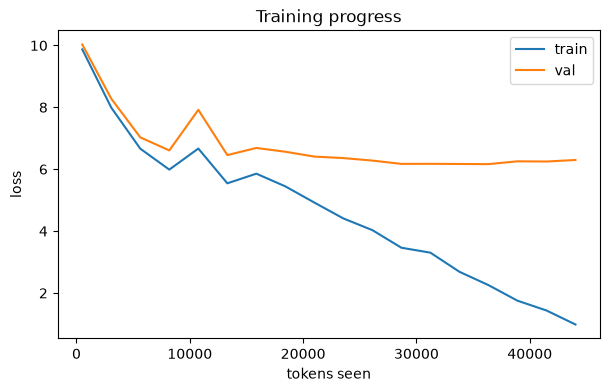

In [33]:
# Quick plot of training progress
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tokens_seen, train_losses, label="train")
ax.plot(tokens_seen, val_losses, label="val")
ax.set_xlabel("tokens seen")
ax.set_ylabel("loss")
ax.legend()
ax.set_title("Training progress")
plt.show()
